# DJF_PR_teleconnection: Structure of Boreal Winter Precipitation Anomalies

The "DJF_PR_teleconnection" notebook evaluates the relationship between ENSO (El Niño-Southern Oscillation) and boreal winter precipitation anomalies, focusing on the region between 60°S and 60°N. It analyses the spatial and temporal structure of precipitation patterns during the DJF period, providing insights into teleconnections and their potential impacts on global climate variability.

## Recommended Observational Datasets

### Temperature Surface (TS)

- **ERSSTv5**: The Extended Reconstructed Sea Surface Temperature version 5 (ERSSTv5) is a global monthly sea surface temperature dataset derived from in situ observations and optimally interpolated. It is widely used for climate studies and trend analysis.

- **HadISSTv1.1**: The Hadley Centre Sea Ice and Sea Surface Temperature dataset version 1.1 (HadISSTv1.1) provides a globally complete dataset of monthly mean sea surface temperatures and sea ice concentrations since 1870.

- **COBE2**: The Centennial In Situ Observation-Based Estimates version 2 (COBE2) provides high-resolution sea surface temperature data, constructed using historical ship-based observations and modern quality control techniques.

## Precipitation (PR)

- **GPCP**: The Global Precipitation Climatology Project (GPCP) dataset combines satellite and ground-based observations to produce global monthly precipitation estimates with near-global coverage since 1979.

- **CMAP**: The CPC Merged Analysis of Precipitation (CMAP) integrates satellite and gauge-based observations to estimate global precipitation, providing valuable insights into climate variability and hydrological processes.

## Dask Cluster 
Start a cluster with multiple cores

In [11]:
from dask.distributed import Client, progress
client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/distributed/node.py:173: ResourceWarning: unclosed <socket.socket fd=291, family=2, type=1, proto=6, laddr=('0.0.0.0', 0)>
  if retries_left < 1:
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37325 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/37325/status,
Dashboard: /proxy/37325/status,Workers: 7
Total threads: 21,Total memory: 765.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33579,Workers: 0
Dashboard: /proxy/37325/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36449,Total threads: 3
Dashboard: /proxy/42821/status,Memory: 109.29 GiB
Nanny: tcp://127.0.0.1:35809,


In [12]:
#This cell must be in all notebooks!
#It allows us to run all the notebooks at once, note that the following cell has a tag "parameters" which allows us to pass in arguments externally using papermill (see mkfigs.sh for details)

#parameters

### USER EDIT start
#esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-11-08-2025-25km-beta-om3-new-um-params/cm3-demo-datastore/cm3-demo-datastore.json'
dpi=300
esm_file_ts = "/scratch/p66/fc6164/SeptSpinupA/ts_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_060201-088912.nc"
esm_file_pr = "/scratch/p66/yz9299/SeptSpinUpA/pr_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_060201-079012.nc"

mylabel = "SeptSpinUpA"
startyear=610
endyear=790
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/scratch/{os.environ['PROJECT']}/{os.environ['USER']}/nesp/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM ts path: ",esm_file_ts)
print("ESM pr path: ",esm_file_pr)

print("Plot folder path: ",plotfolder)

ESM ts path:  /scratch/p66/fc6164/SeptSpinupA/ts_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_060201-088912.nc
ESM pr path:  /scratch/p66/yz9299/SeptSpinUpA/pr_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_060201-079012.nc
Plot folder path:  /scratch/eg3/cxc548/nesp/


## Datasets

In [13]:
from esmvalcore.dataset import Dataset

In [14]:
model_ctrlts_datasets = {
"ACCESS-ESM1-5": 
    Dataset(
    short_name='ts',
    project='CMIP6',
    mip="Amon",
    exp="piControl",
    ensemble="r1i1p1f1",
    timerange="0900101/11000101",
    dataset="ACCESS-ESM1-5",
    grid="gn"
),}

model_ctrlpr_datasets = {
"ACCESS-ESM1-5": 
    Dataset(
    short_name='pr',
    project='CMIP6',
    mip="Amon",
    exp="piControl",
    ensemble="r1i1p1f1",
    timerange="0900101/11000101",
    dataset="ACCESS-ESM1-5",
    grid="gn"
),}


obs_ts_datasets = {
    "ERA-Interim":
    Dataset(
    short_name='ts',
    dataset='ERA-Interim',
    mip="Amon",
    project='OBS6',
    type='reanaly',
    tier=3)
# "HadISST": 
#     Dataset(
#     short_name='ts',
#     dataset='HadISST',
#     mip="Amon",
#     project='OBS',
#     type='reanaly',
#     tier=2),
# "ERSSTv5":
#     Dataset(
#     short_name='tos',
#     dataset='NOAA-ERSSTv5',
#     mip="Omon",
#     project='OBS6',
#     type='reanaly',
#     tier=2)
}


obs_pr_datasets = {
    "ERA-Interim":
    Dataset(
    short_name='pr',
    dataset='ERA-Interim',
    mip="Amon",
    project='OBS6',
    type='reanaly',
    tier=3)
}
# "GPCP-SG": 
#     Dataset(
#     short_name='pr',
#     dataset='GPCP-SG',
#     mip="Amon",
#     project='OBS',
#     type='atmos',
#     tier=2),
# "CMAP": 
#     Dataset(
#     short_name='pr',
#     dataset='CMAP',
#     mip="Amon",
#     project='OBS6',
#     type='reanaly',
#     timerange="197901/202408",
#     tier=2)


## Add Ancillary files


In [15]:
for name, dataset in model_ctrlpr_datasets.items():
    dataset.add_supplementary(short_name='sftlf', mip="fx")
    dataset.add_supplementary(short_name="areacella", mip="fx")
for name, dataset in model_ctrlts_datasets.items():
    dataset.add_supplementary(short_name='sftlf', mip="fx")
    dataset.add_supplementary(short_name="areacella", mip="fx")

In [16]:
model_ctrlts_datasets = {name: dataset.load() for name, dataset in model_ctrlts_datasets.items()}
model_ctrlpr_datasets = {name: dataset.load() for name, dataset in model_ctrlpr_datasets.items()}

obs_ts_datasets = {name: dataset.load() for name, dataset in obs_ts_datasets.items()}
obs_pr_datasets = {name: dataset.load() for name, dataset in obs_pr_datasets.items()}

import iris
from iris.util import equalise_attributes

esm16cube_ts = iris.load_cube(esm_file_ts,'surface_temperature')

esm16cube_pr = iris.load_cube(esm_file_pr,'precipitation_flux')



/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:405: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, remove_version, more_info)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:405: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, remove_version, more_info)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/esmvalcore/config/_config_valid

In [17]:
from esmvalcore.preprocessor import anomalies
from esmvalcore.preprocessor import area_statistics
from esmvalcore.preprocessor import seasonal_statistics
from esmvalcore.preprocessor import rolling_window_statistics
from esmvalcore.preprocessor import convert_units
from esmvalcore.preprocessor import extract_region
from esmvalcore.preprocessor import extract_season
from esmvalcore.preprocessor import extract_month
from esmvalcore.preprocessor import extract_time
from esmvalcore.preprocessor import detrend
from esmvalcore.preprocessor import regrid
from esmvalcore.preprocessor import mask_landsea
import iris

import matplotlib.pyplot as plt
import iris.quickplot as qplt
import numpy as np


In [18]:
def sst_enso(cube,start,end):
    nino34_latext_region = {"start_longitude": 190., "end_longitude": 240., "start_latitude": -5., "end_latitude": 5.}
    cube = extract_time(cube, start_year=start, end_year=end, start_month=1, end_month=12, start_day=1, end_day=31)
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = convert_units(cube, units="degC")
    cube = mask_landsea(cube, mask_out="land") #shp or land fraction
    cube = anomalies(cube, period="monthly")
    cube = detrend(cube, dimension="time", method="linear")
    cube = extract_region(cube, **nino34_latext_region)
    print("After extract_region:", cube.shape) 
    cube = area_statistics(cube,operator='mean')
    cube = extract_season(cube, season="DJF")
    print("After extract_season:", cube.shape)
    cube = seasonal_statistics(cube, operator="mean", seasons=("DJF","MAMJJASON"))
    
    return cube


def pr_global(cube,start,end):
    region = {"start_longitude": 0., "end_longitude": 360., "start_latitude": -60., "end_latitude": 60.}
    cube = extract_time(cube, start_year=start, end_year=end, start_month=1, end_month=12, start_day=1, end_day=31)
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = convert_units(cube, units="mm/day")
    cube = anomalies(cube, period="monthly")
    cube = detrend(cube, dimension="time", method="linear")
    cube = extract_season(cube, season="DJF")
    print("After extract_season:", cube.shape)
    cube = seasonal_statistics(cube, operator="mean", seasons=("DJF","MAMJJASON"))
    cube = extract_region(cube, **region)

    return cube   



In [19]:
print(esm16cube_pr)

precipitation_flux / (kg m-2 s-1)   (longitude: 192; latitude: 145; time: 2268)
    Dimension coordinates:
        longitude                             x              -          -
        latitude                              -              x          -
        time                                  -              -          x
    Cell methods:
        0                           area: time: mean
    Attributes:
        Conventions                 'CF-1.7 CMIP-6.2'
        STASH                       m01s05i216
        activity_id                 'CMIP'
        branch_method               'standard'
        branch_time_in_child        0.0
        branch_time_in_parent       54786.0
        comment                     'includes both liquid and solid phases'
        creation_date               '2025-10-07T04:08:10Z'
        creator_email               'u6660070@anu.edu.au'
        creator_name                'Rhaegar'
        creator_organisation        'access-nri'
        creator_url  

In [20]:
model_ctrlts_datasets_prep = {name: sst_enso(dataset,900,1100) for name, dataset in model_ctrlts_datasets.items()}
model_ctrlpr_datasets_prep = {name: pr_global(dataset,900,1100) for name, dataset in model_ctrlpr_datasets.items()}

esm16cube_ts_t = esm16cube_ts.transpose((2,1,0))

model_ts_datasets_prep = sst_enso(esm16cube_ts,startyear,endyear)
esm16cube_pr_t = esm16cube_pr.transpose((2,1,0))

#print(esm16cube_pr_t.coords())
model_pr_datasets_prep = pr_global(esm16cube_pr,startyear,endyear) 

obs_ts_datasets_prep = {name: sst_enso(dataset,1979,2014) for name, dataset in obs_ts_datasets.items()}
obs_pr_datasets_prep = {name: pr_global(dataset,1979,2014) for name, dataset in obs_pr_datasets.items()}

After extract_region: (2397, 10, 50)
After extract_season: (598,)
After extract_season: (598, 180, 360)
After extract_region: (2172, 10, 50)
After extract_season: (543,)
After extract_season: (543, 180, 360)
After extract_region: (432, 10, 50)
After extract_season: (108,)
After extract_season: (108, 180, 360)


## Calculate Linear regression

In [21]:
import iris.util

def lin_regress_matrix(cubeA, cubeB):
    """
    Calculate the linear regression of cubeA on cubeB using matrix operations.

    Parameters
    ----------
    cubeA: iris.cube.Cube
        The 2D input cube for which the regression is calculated.
    
    cubeB: iris.cube.Cube
        The cube used as the independent variable in the regression.

    Returns
    -------
    iris.cube.Cube
        A new cube containing the slope of the regression for each spatial point.
    """

    A_data = cubeA.data.reshape(cubeA.shape[0], -1)  # Shape (time, spatial_points)

    B_data = cubeB.data.flatten()  # Shape (time,)

    # Add intercept term by stacking a column of ones with cubeB
    B_with_intercept = np.vstack([B_data, np.ones_like(B_data)]).T

    # Solve the linear equations using least squares method
    coefs, _, _, _ = np.linalg.lstsq(B_with_intercept, A_data, rcond=None)
    
    # Extract slopes from coefficients
    slopes = coefs[0].reshape(cubeA.shape[1], cubeA.shape[2])

    # Create a new Iris Cube for the regression results
    result_cube = iris.cube.Cube(slopes, long_name='regression ENSO SSTA',
                                 dim_coords_and_dims=[(cubeA.coord('latitude'), 0),
                                                      (cubeA.coord('longitude'), 1)])

    return result_cube

In [22]:
reg2_ctrlmod = lin_regress_matrix(model_ctrlpr_datasets_prep["ACCESS-ESM1-5"], model_ctrlts_datasets_prep["ACCESS-ESM1-5"])
reg2_mod = lin_regress_matrix(model_pr_datasets_prep, model_ts_datasets_prep)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:339: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:339: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:339: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]


In [23]:
reg2_obs = lin_regress_matrix(obs_pr_datasets_prep["ERA-Interim"], obs_ts_datasets_prep["ERA-Interim"])

process = {"ERA-Interim":reg2_obs,"ESM1.5 piControl":reg2_ctrlmod, mylabel:reg2_mod} 

In [24]:
print(obs_pr_datasets_prep["ERA-Interim"].data.min(), obs_ts_datasets_prep["ERA-Interim"].data.min())
print(model_ctrlpr_datasets_prep["ACCESS-ESM1-5"].data.min(), model_ctrlts_datasets_prep["ACCESS-ESM1-5"].data.min())

-18.401222 -1.859357
-19.74309 -3.1043675


In [25]:
#create shapely geometry from lat/lon..
from shapely import box
import numpy as np
import shapely.vectorized as shp_vect

def get_sea_mask(cube_0time):
    region = {"start_longitude": 0., "end_longitude": 360., "start_latitude": -60., "end_latitude": 60.}
    cube = mask_landsea(cube_0time, mask_out="sea")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **region)
    return cube.data.mask
    
# Create a set of x,y points from the cube
def mask_pacific(cube, seamask):
    region = box(120.,-15.,290.,15) #remove land from mask?
    x_p, y_p = np.meshgrid(
        cube.coord(axis="X").points,
        cube.coord(axis="Y").points,
    )

    mask = shp_vect.contains(region, x_p, y_p)
    #add sea mask to include land in pacific
    mask = mask.astype(int) + seamask.astype(int)
    use_mask = np.zeros_like(mask, bool)
    use_mask[mask == 2] = True
    
    # cube.data.mask = use_mask
    cube.data = np.ma.MaskedArray(cube.data, mask=use_mask)
    return cube

In [26]:
# mask and compute 
obs_seamask = get_sea_mask(obs_pr_datasets["ERA-Interim"][0]) ##preproc?
ctrlmod_seamask = get_sea_mask(model_ctrlts_datasets["ACCESS-ESM1-5"][0])


In [27]:

#esm16cube_ts_t = esm16cube_ts.transpose([2,1,0])
mod_seamask = get_sea_mask(esm16cube_ts[0])
#reg2_obs_masked = mask_pacific(reg2_obs, obs_seamask)
#reg2_ctrlmod_masked = mask_pacific(reg2_ctrlmod, ctrlmod_seamask)
#reg2_mod_masked = mask_pacific(reg2_mod, mod_seamask)


#rmse = np.sqrt(np.mean((reg2_obs_masked.data- reg2_mod_masked.data) ** 2))
#print(rmse)

process = {"Observation":reg2_obs,"ACCESS-ESM1-5":reg2_ctrlmod,mylabel:reg2_mod } 

# Diagnostic Level 1

In [28]:
reg2_mod.data.min(), reg2_mod.data.max(), reg2_obs.data.min(), reg2_obs.data.max(), reg2_obs.data.mean()

(-5.998359, 4.1958404, -2.4520717, 6.8705115, 0.005608392)

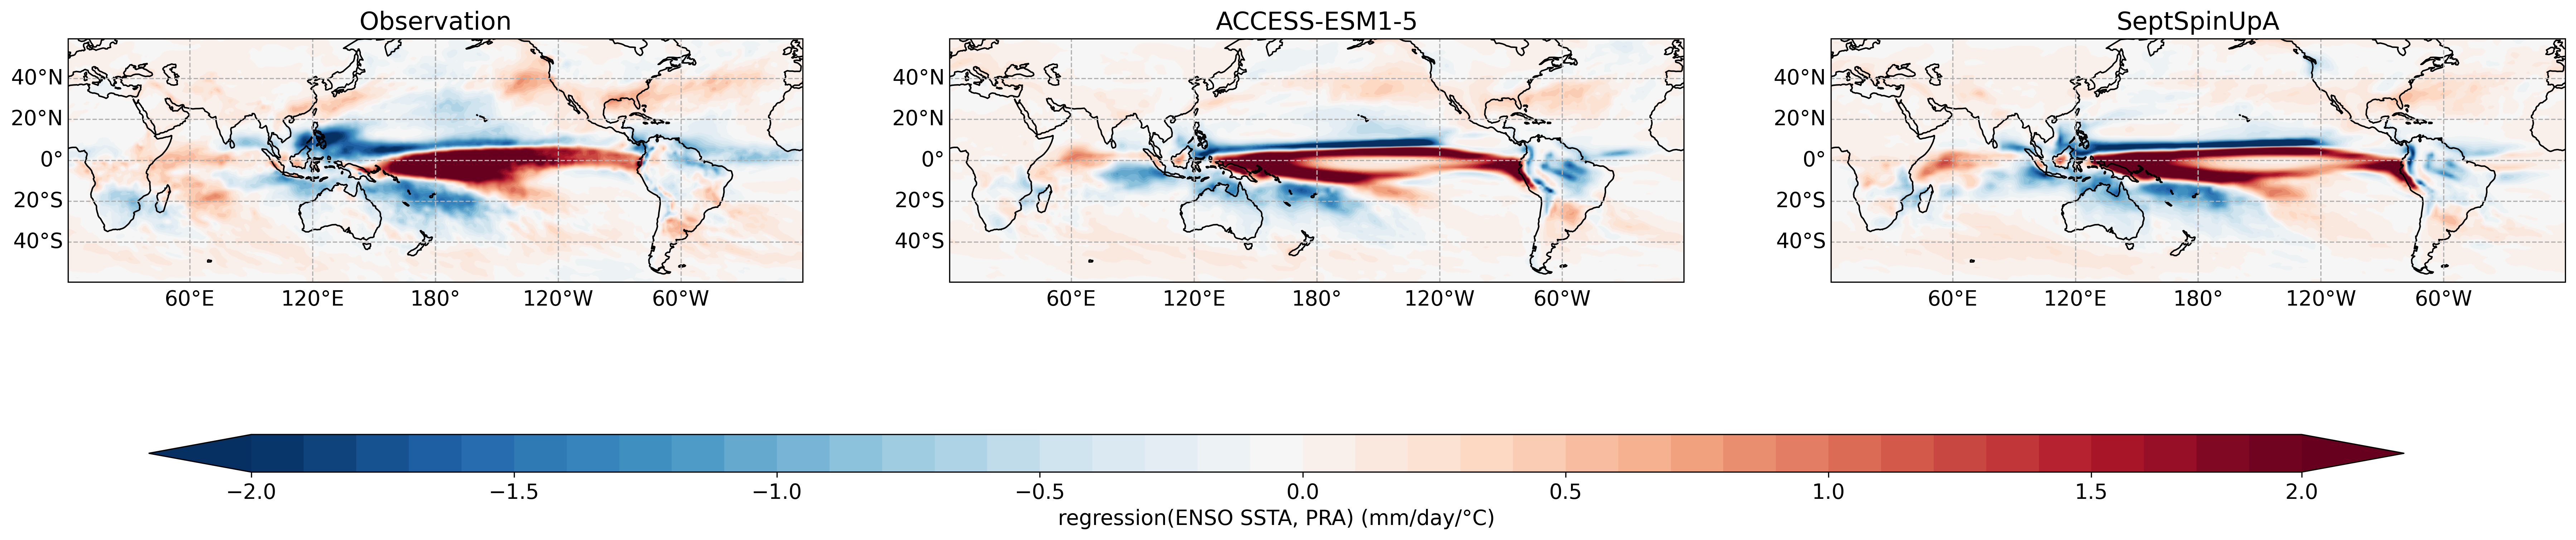

In [29]:
import iris.plot as iplt
import matplotlib.colors as mcolors
import cartopy.feature as cfeature
import cartopy.crs as ccrs

fig = plt.figure(figsize=(30, 7))
proj = ccrs.PlateCarree(central_longitude=180)
plt.rcParams.update({'font.size': 14})

i =131

for label, cube in process.items():
    
    ax1 = plt.subplot(i,projection=proj)
    ax1.coastlines()
    cf1 = iplt.contourf(cube, levels=np.arange(-2,2,0.1), extend='both', cmap='RdBu_r')
    ax1.set_title(label)
    gl1 = ax1.gridlines(draw_labels=True, linestyle='--')
    gl1.top_labels = False
    gl1.right_labels = False
    i+=1

#plt.text(0.1, -0.3, f'RMSE: {rmse:.2f} ', fontsize=12, ha='left',
#         transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Add a single colorbar at the bottom
cax = plt.axes([0.15,0.08,0.7,0.05])
cbar = fig.colorbar(cf1, cax=cax, orientation='horizontal', extend='both', ticks=np.arange(-2,2.5,0.5))
cbar.set_label('regression(ENSO SSTA, PRA) (mm/day/°C)')

## Diagnostics level 2 
el nino, la nina, PRA mm/day

In [30]:
from esmvalcore.preprocessor import mask_above_threshold
from esmvalcore.preprocessor import mask_below_threshold
from esmvalcore.preprocessor import rolling_window_statistics
from esmvalcore.preprocessor import extract_month
from esmvalcore.preprocessor import extract_time
import numpy as np

def nino3_4ssta(cube,start,end):
    cube = extract_region(cube, 150, 270, -5, 5)
    cube = extract_time(cube, start_year=start, end_year=end, start_month=1, end_month=12, start_day=1, end_day=31)
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    # triangle weighted- double smoothed
    cube = anomalies(cube, period='monthly')  
    cube = rolling_window_statistics(cube, coordinate='time', operator='mean', window_length=5)
#    cube = rolling_window_statistics(cube, coordinate='time', operator='mean', window_length=5)
    cube = area_statistics(cube, 'mean')
    cube = extract_month(cube, 12)
    #divide std?
    return cube
    
def mask_to_years(events):
    maskedTime = np.ma.masked_array(events.coord('time').points, mask=events.data.mask)
    return [events.coord('time').units.num2date(time).year for time in maskedTime.compressed()]
    
def enso_events(cube):
    std = cube.data.std()
    a_events = mask_to_years(mask_above_threshold(cube.copy(), -0.75 * std))
    o_events = mask_to_years(mask_below_threshold(cube.copy(), 0.75 * std))
    return {'nina':a_events, 'nino':o_events}

In [31]:
prep_datasets = {'ERA-Interim':[obs_pr_datasets_prep["ERA-Interim"],obs_ts_datasets_prep["ERA-Interim"]],
                "ACCESS-ESM1-5":[model_ctrlpr_datasets_prep["ACCESS-ESM1-5"],model_ctrlts_datasets_prep["ACCESS-ESM1-5"]],
                mylabel:[model_pr_datasets_prep,model_ts_datasets_prep]   }
ts_datasets = {**obs_ts_datasets,**model_ctrlts_datasets, mylabel:esm16cube_ts}

In [32]:
events_dict = {}
start=[1979,900,startyear]
end=[2014,1100,endyear]
i=0
for name, ds in ts_datasets.items(): #ts
    nino_res = nino3_4ssta(ds,start[i],end[i])
    events_dict[name] = enso_events(nino_res)
    i+=1

cubes_dict = {}
for ds_name, events in events_dict.items():
    print(ds_name)
    cubes_dict[ds_name] = {}
    for enso, years in events.items():
        # cube pr and cube ts
        print(enso, len(years), 'number of event years')
        print(years)
        year_enso = iris.Constraint(time=lambda cell: (cell.point.year-1) in years)
        cube_pr = prep_datasets[ds_name][0].extract(year_enso) # extract from pr cube
        # cube_ts = prep_datasets[ds_name][1].extract(year_enso) #not req
        cubes_dict[ds_name][enso] = cube_pr

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/iris/cube.py:4881: IrisIgnoringBoundsWarning: The bounds of coordinate 'time' were ignored in the rolling window operation.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/iris/cube.py:4881: IrisIgnoringBoundsWarning: The bounds of coordinate 'time' were ignored in the rolling window operation.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/iris/cube.py:4881: IrisIgnoringBoundsWarning: The bounds of coordinate 'time' were ignored in the rolling window operation.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:339: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]


ERA-Interim
nina 7 number of event years
[1984, 1988, 1998, 1999, 2007, 2010, 2011]
nino 9 number of event years
[1982, 1986, 1987, 1991, 1994, 1997, 2002, 2006, 2009]
ACCESS-ESM1-5
nina 49 number of event years
[903, 905, 913, 917, 919, 921, 926, 928, 929, 940, 943, 945, 947, 950, 953, 966, 969, 974, 979, 982, 989, 995, 998, 1005, 1010, 1011, 1014, 1015, 1022, 1029, 1030, 1035, 1038, 1039, 1042, 1047, 1052, 1056, 1059, 1061, 1065, 1068, 1071, 1073, 1075, 1078, 1086, 1090, 1097]
nino 50 number of event years
[900, 909, 910, 912, 915, 922, 923, 925, 932, 934, 936, 939, 942, 949, 951, 952, 955, 958, 968, 972, 973, 981, 983, 985, 986, 994, 1006, 1009, 1012, 1013, 1018, 1019, 1021, 1028, 1037, 1040, 1041, 1043, 1046, 1053, 1055, 1058, 1067, 1070, 1074, 1076, 1079, 1085, 1087, 1092]
SeptSpinUpA
nina 45 number of event years
[617, 619, 620, 631, 634, 637, 638, 641, 647, 649, 660, 661, 663, 666, 669, 672, 675, 676, 678, 681, 687, 689, 698, 708, 709, 712, 713, 717, 726, 729, 730, 732, 736, 741

In [33]:
print(events_dict['ERA-Interim'])
print(cubes_dict['ERA-Interim']['nina'].coord('time'))
print(cubes_dict['ERA-Interim']['nino'].coord('time'))


 # 1985-01-15 00:00:00, 1989-01-15 00:00:00, 1999-01-15 00:00:00,
 #        2000-01-15 12:00:00, 2008-01-15 12:00:00, 2011-01-15 00:00:00,
 #        2012-01-15 12:00:00]

{'nina': [1984, 1988, 1998, 1999, 2007, 2010, 2011], 'nino': [1982, 1986, 1987, 1991, 1994, 1997, 2002, 2006, 2009]}
DimCoord :  time / (days since 1850-1-1 00:00:00, standard calendar)
    points: [
        1985-01-15 00:00:00, 1989-01-15 00:00:00, 1999-01-15 00:00:00,
        2000-01-15 12:00:00, 2008-01-15 12:00:00, 2011-01-15 00:00:00,
        2012-01-15 12:00:00]
    bounds: [
        [1984-12-01 00:00:00, 1985-03-01 00:00:00],
        [1988-12-01 00:00:00, 1989-03-01 00:00:00],
        [1998-12-01 00:00:00, 1999-03-01 00:00:00],
        [1999-12-01 00:00:00, 2000-03-01 00:00:00],
        [2007-12-01 00:00:00, 2008-03-01 00:00:00],
        [2010-12-01 00:00:00, 2011-03-01 00:00:00],
        [2011-12-01 00:00:00, 2012-03-01 00:00:00]]
    shape: (7,)  bounds(7, 2)
    dtype: float64
    standard_name: 'time'
    long_name: 'time'
    var_name: 'time'
DimCoord :  time / (days since 1850-1-1 00:00:00, standard calendar)
    points: [
        1983-01-15 00:00:00, 1987-01-15 00:00:00, 

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/iris/coords.py:323: DeprecationWarning: This method is no longer needed due to cftime's improved handling of long time intervals.
  if not self.units.is_long_time_interval():


In [34]:
from esmvalcore.preprocessor import climate_statistics
process = {'La Nina' : {}, 'El Nino' : {}}

for key, dictcubes in cubes_dict.items():
    for enso, cube in dictcubes.items():
        # reg_cube = lin_regress_matrix(cubes[0], cubes[1]) #no regression just anomalies
        acube = climate_statistics(cube, operator='mean')
        if enso == 'nina':
            enso = "La Nina"
        else:
            enso = "El Nino"
        process[enso][key] = acube#mask_pacific(acube, mod_seamask)



# print(np.sqrt(np.mean((process['obs'].data - process['ACCESS-ESM1-5'].data) ** 2)))

In [35]:
print(np.sqrt(np.mean((process['La Nina']['ERA-Interim'].data - process['La Nina']['ACCESS-ESM1-5'].data) ** 2)))
print(process['La Nina']['ERA-Interim'].coord('time'))
print(process['El Nino']['ERA-Interim'].coord('time'))

0.657131
DimCoord :  time / (days since 1850-1-1 00:00:00, standard calendar)
    points: [1998-07-17 00:00:00]
    bounds: [[1984-12-01 00:00:00, 2012-03-01 00:00:00]]
    shape: (1,)  bounds(1, 2)
    dtype: float64
    standard_name: 'time'
    long_name: 'time'
    var_name: 'time'
DimCoord :  time / (days since 1850-1-1 00:00:00, standard calendar)
    points: [1996-07-16 00:00:00]
    bounds: [[1982-12-01 00:00:00, 2010-03-01 00:00:00]]
    shape: (1,)  bounds(1, 2)
    dtype: float64
    standard_name: 'time'
    long_name: 'time'
    var_name: 'time'


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.05/lib/python3.11/site-packages/iris/coords.py:323: DeprecationWarning: This method is no longer needed due to cftime's improved handling of long time intervals.
  if not self.units.is_long_time_interval():


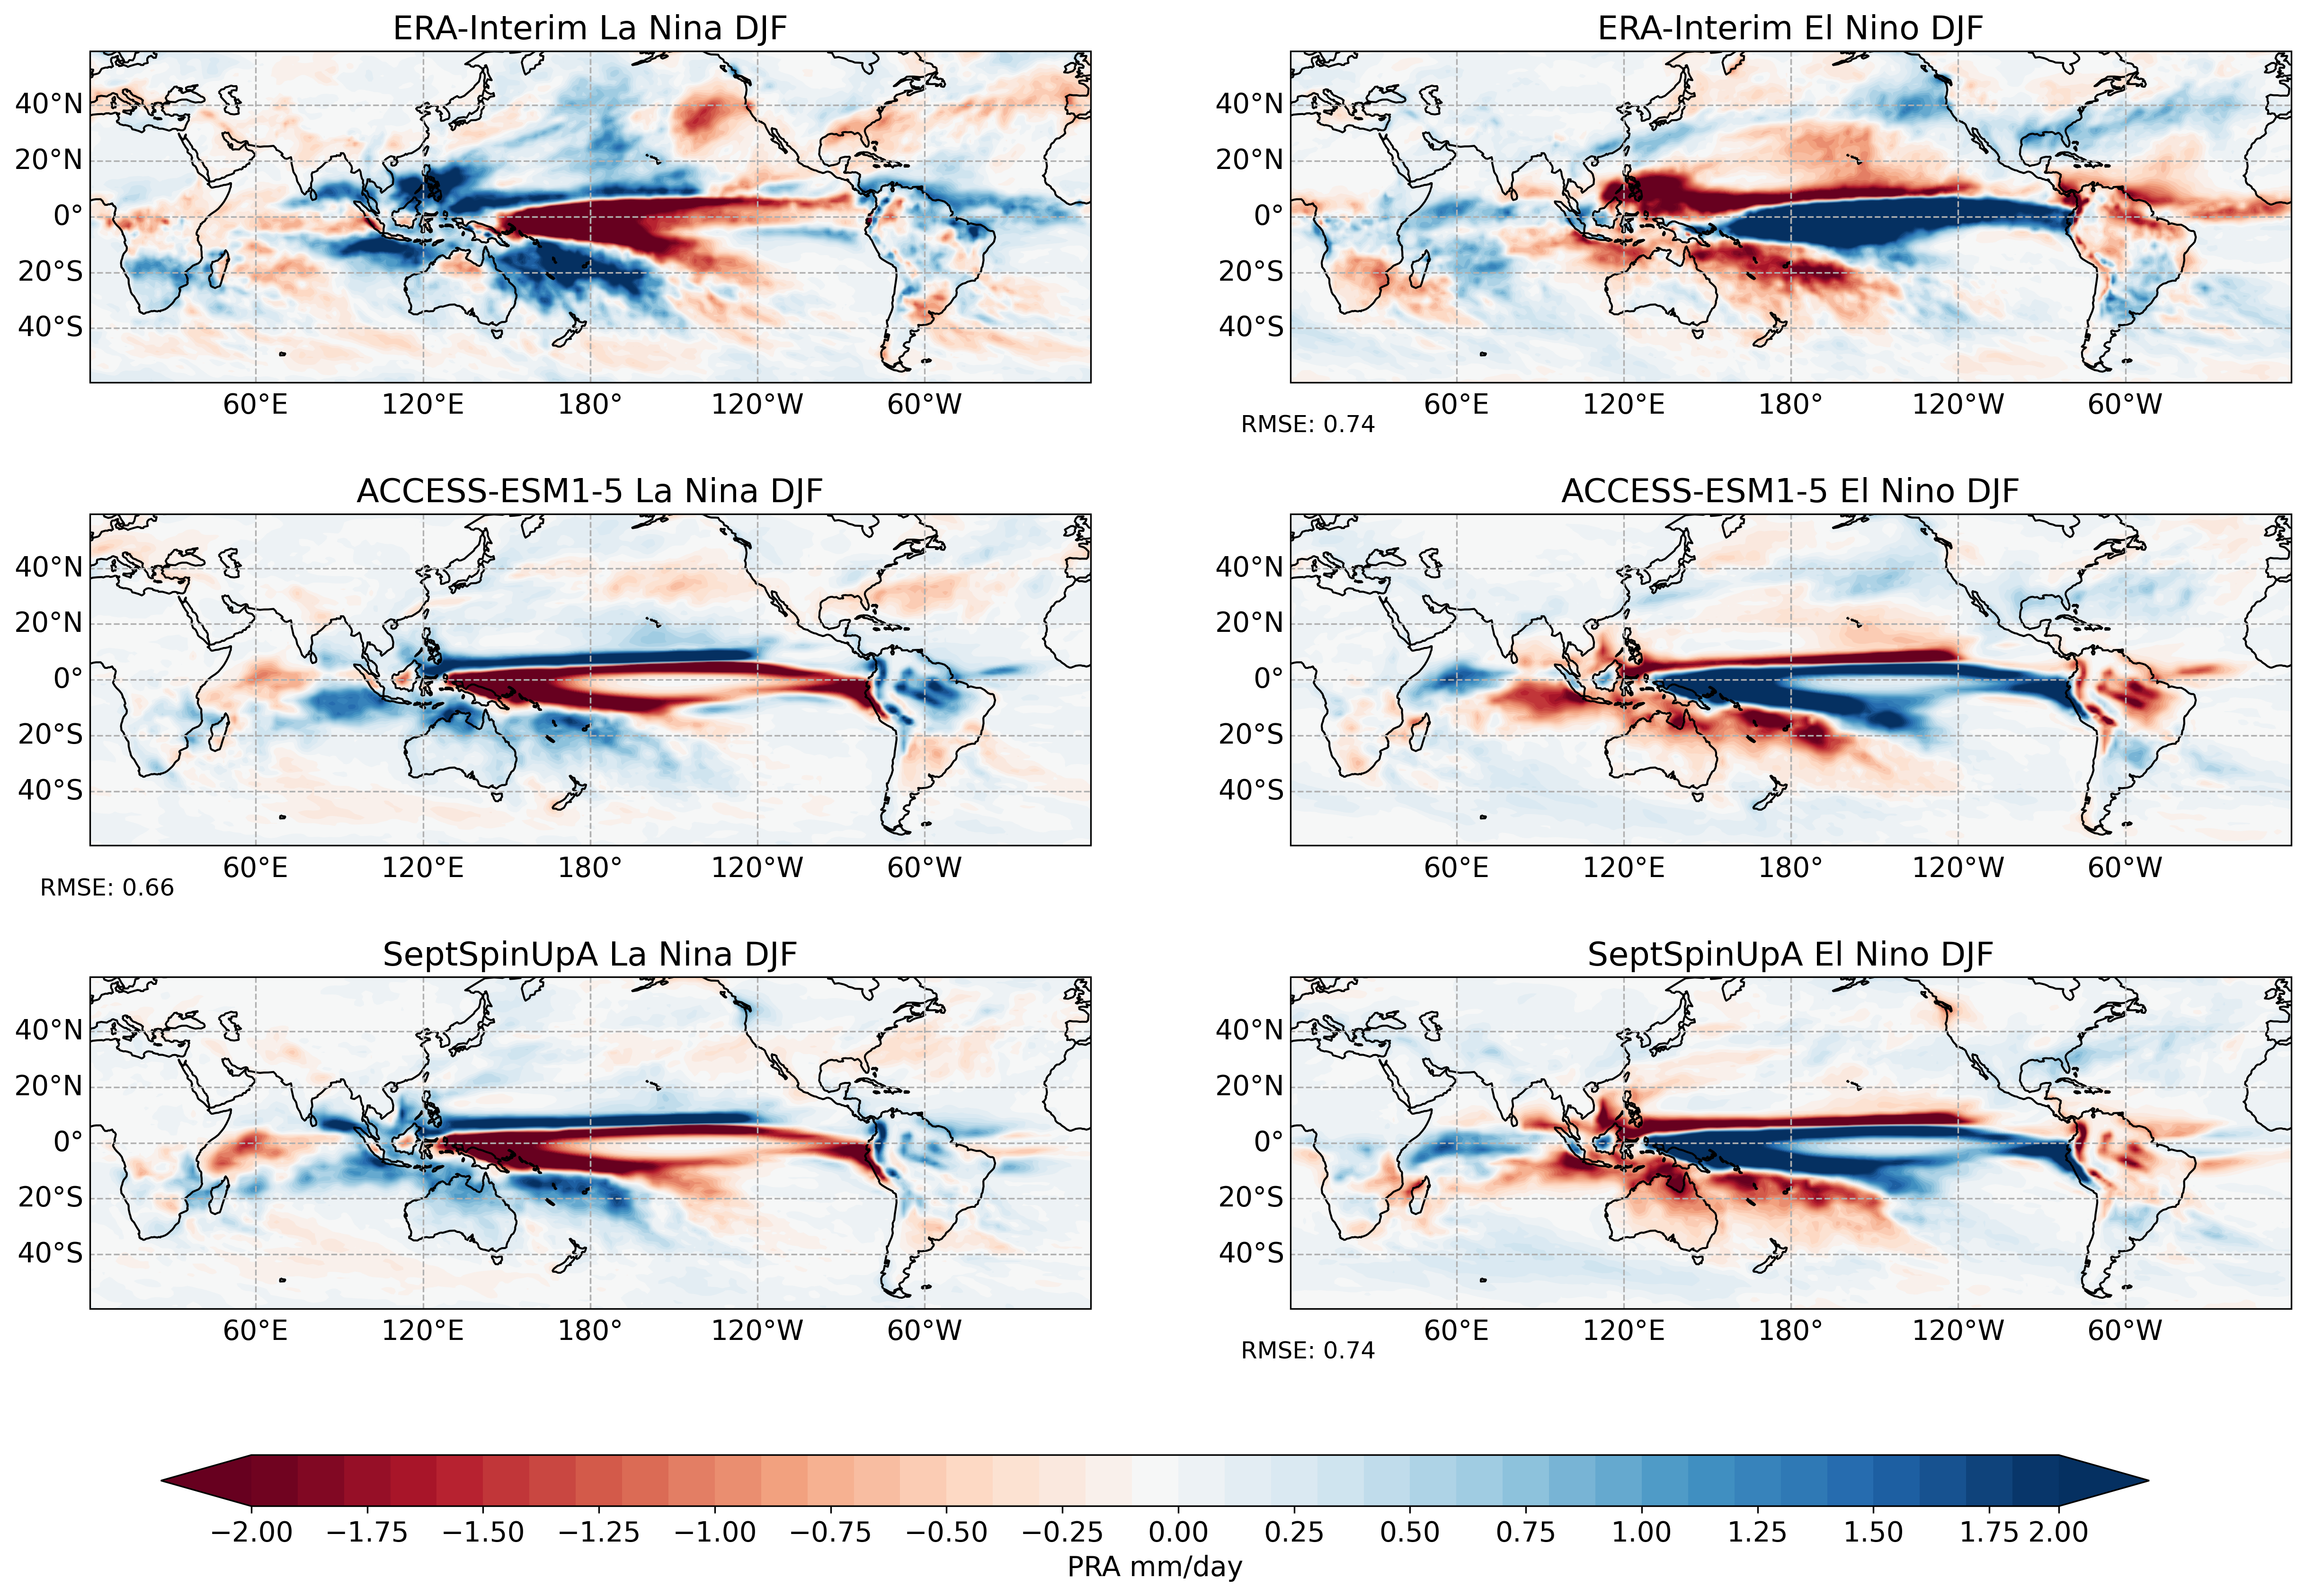

In [36]:
fig = plt.figure(figsize=(20, 12)) #func? params - process, rmse
proj = ccrs.PlateCarree(central_longitude=180)

i =321
positions = [321,323,325,322,324,326]
counter=0
for label, d_cubes in process.items():
    for ds_name, cube in d_cubes.items():
        
        ax1 = plt.subplot(positions[counter],projection=proj)
        ax1.coastlines()
        cf1 = iplt.contourf(cube, levels=np.arange(-2,2,0.1), extend='both', cmap='RdBu')
        ax1.set_title(f'{ds_name} {label} DJF')
        gl1 = ax1.gridlines(draw_labels=True, linestyle='--')
        gl1.top_labels = False
        gl1.right_labels = False
        
        if i%2 == 0: #obs first, odd, prev
            rmse = np.sqrt(np.mean((process[label]["ERA-Interim"].data - process[label][mylabel].data) ** 2))
            plt.text(-0.05, -0.15, f'RMSE: {rmse:.2f} ', fontsize=12, ha='left',
                 transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        i+=1
        counter+=1




cax = plt.axes([0.15,0.01,0.7,0.03])
cbar = fig.colorbar(cf1, cax=cax, orientation='horizontal', extend='both', ticks=np.arange(-2,2.1,0.25))
cbar.set_label('PRA mm/day')

Figure 2: structure of precipitation anomalies (PRA) on Earth (between 60°S-60°N), showing the location of PRA associated with La Niña (top) and El Niño (bottom). It shows that teleconnections are not totally symmetric (e.g. East Africa or South-East South America). It also shows that some model biases are more related to one phase of ENSO than the other: here the teleconnection bias in the South Pacific is more related to a too weak increase of PR during El Niño and the bias in South Africa is more related to an absence of teleconnection during La Niña.